# 🚀 AI-Powered Resume Screening & Candidate Ranking System  
## Industry-Level Machine Learning Project  

### 👩‍💻 Submitted By:
Raksha G L  
Don Bosco Institute of Technology  

---

## 📌 Project Overview

This project builds an intelligent resume screening system that leverages 
Natural Language Processing (NLP) and Transformer-based embeddings 
to automatically evaluate and rank candidates against a job description.

Unlike traditional keyword matching systems, this model uses 
BERT-based semantic similarity to understand contextual meaning.

---

## 🎯 Business Problem

Recruiters receive hundreds of resumes per job posting.
Manual screening is:
- Time-consuming
- Inconsistent
- Prone to bias

This system automates the screening process by:
✔ Extracting skills  
✔ Measuring semantic similarity  
✔ Ranking candidates  
✔ Providing explainable scores  

---

## 🛠️ Technologies Used

- Python
- Pandas
- Scikit-learn
- Sentence Transformers (BERT)
- Cosine Similarity
- Regex (Skill Extraction)
- Matplotlib
- Streamlit (Deployment Ready)

---

## 🏗️ System Architecture

1. Resume Collection
2. Text Cleaning & Preprocessing
3. Skill Extraction
4. BERT Embedding Generation
5. Semantic Similarity Calculation
6. Candidate Ranking
7. Visualization & Reporting

In [1]:
!pip install sentence-transformers

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
import os
os.getcwd()

'C:\\Users\\WIN11'

In [4]:
os.listdir()

['.anaconda',
 '.cache',
 '.conda',
 '.continuum',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.vscode',
 'anaconda3',
 'AppData',
 'Application Data',
 'archive (1).zip',
 'archive (2).zip',
 'Contacts',
 'Cookies',
 'dataset_folder',
 'Downloads',
 'Favorites',
 'IntelGraphicsProfiles',
 'label_encoder.pkl',
 'Links',
 'Local Settings',
 'Machine_Learning_Task_2.ipynb',
 'Machine_Learning_Task_3.ipynb',
 'Music',
 'My Documents',
 'NetHood',
 'node_modules',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{81303931-e61d-11f0-b7e0-485f9977582e}.TM.blf',
 'NTUSER.DAT{81303931-e61d-11f0-b7e0-485f9977582e}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{81303931-e61d-11f0-b7e0-485f9977582e}.TMContainer00000000000000000002.regtrans-ms',
 'NTUSER.DAT{d98c2ba8-4e02-11f0-b7c8-ed96f4eb7445}.TxR.0.regtrans-ms',
 'NTUSER.DAT{d98c2ba8-4e02-11f0-b7c8-ed96f4eb7445}.TxR.1.regtrans-ms',
 'NTUSER.DAT{d98c2ba8-4e02-11f0-b7c8-ed96f4eb7445}

In [5]:
import zipfile

zip_path = "archive (2).zip"   


with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("resume_data")

print("Extraction Completed ✅")

Extraction Completed ✅


In [6]:
import os

os.listdir("resume_data")

['resume_data_for_ranking.csv']

In [7]:
df = pd.read_csv("resume_data/resume_data_for_ranking.csv")
df.head()

,address,career_objective,skills,educational_institution_name,degree_names,passing_years,educational_results,result_types,major_field_of_studies,professional_company_names,...,online_links,issue_dates,expiry_dates,job_position_name,educationaL_requirements,experiencere_requirement,age_requirement,responsibilities.1,skills_required,matched_score
0,NaN,Big data analytics working and database wareho...,"['Big Data', 'Hadoop', 'Hive', 'Python', 'Mapr...",['The Amity School of Engineering & Technology...,['B.Tech'],['2019'],['N/A'],[None],['Electronics'],['Coca-COla'],...,NaN,NaN,NaN,Senior Software Engineer,B.Sc in Computer Science & Engineering from a ...,At least 1 year,NaN,Technical Support\nTroubleshooting\nCollaborat...,NaN,0.850000
1,NaN,Fresher looking to join as a data analyst and ...,"['Data Analysis', 'Data Analytics', 'Business ...","['Delhi University - Hansraj College', 'Delhi ...","['B.Sc (Maths)', 'M.Sc (Science) (Statistics)']","['2015', '2018']","['N/A', 'N/A']","['N/A', 'N/A']","['Mathematics', 'Statistics']",['BIB Consultancy'],...,NaN,NaN,NaN,Machine Learning (ML) Engineer,M.Sc in Computer Science & Engineering or in a...,At least 5 year(s),NaN,Machine Learning Leadership\nCross-Functional ...,NaN,0.750000
2,NaN,NaN,"['Software Development', 'Machine Learning', '...","['Birla Institute of Technology (BIT), Ranchi']",['B.Tech'],['2018'],['N/A'],['N/A'],['Electronics/Telecommunication'],['Axis Bank Limited'],...,NaN,NaN,NaN,"Executive/ Senior Executive- Trade Marketing, ...",Master of Business Administration (MBA),At least 3 years,NaN,"Trade Marketing Executive\nBrand Visibility, S...",Brand Promotion\nCampaign Management\nField Su...,0.416667
3,NaN,To obtain a position in a fast-paced business ...,"['accounts payables', 'accounts receivables', ...","['Martinez Adult Education, Business Training ...",['Computer Applications Specialist Certificate...,['2008'],[None],[None],['Computer Applications'],"['Company Name ï¼ City , State', 'Company Name...",...,NaN,NaN,NaN,Business Development Executive,Bachelor/Honors,1 to 3 years,Age 22 to 30 years,Apparel Sourcing\nQuality Garment Sourcing\nRe...,Fast typing skill\nIELTSInternet browsing & on...,0.760000
4,NaN,Professional accountant with an outstanding wo...,"['Analytical reasoning', 'Compliance testing k...",['Kent State University'],['Bachelor of Business Administration'],[None],['3.84'],[None],['Accounting'],"['Company Name', 'Company Name', 'Company Name...",...,[None],[None],"['February 15, 2021']",Senior iOS Engineer,Bachelor of Science (BSc) in Computer Science,At least 4 years,NaN,iOS Lifecycle\nRequirement Analysis\nNative Fr...,iOS\niOS App Developer\niOS Application Develo...,0.650000


In [8]:


df['Full_Resume_Text'] = (
    df['career_objective'].fillna('') + ' ' +
    df['skills'].fillna('') + ' ' +
    df['degree_names'].fillna('') + ' ' +
    df['major_field_of_studies'].fillna('')
)

df['Full_Resume_Text'].head()

0    Big data analytics working and database wareho...
1    Fresher looking to join as a data analyst and ...
2     ['Software Development', 'Machine Learning', ...
3    To obtain a position in a fast-paced business ...
4    Professional accountant with an outstanding wo...
Name: Full_Resume_Text, dtype: object

In [9]:
import re

def clean_text(text):
    text = re.sub(r'\[|\]|\'', '', str(text))  job_description = """
We are hiring a Machine Learning Engineer with strong experience in 
Python, Machine Learning, Deep Learning, NLP, Data Analysis, and Scikit-learn.
"""
    text = re.sub(r'\W', ' ', text)            
    text = text.lower()
    return text

df['Cleaned_Resume'] = df['Full_Resume_Text'].apply(clean_text)

SyntaxError: invalid syntax (2318407984.py, line 4)

In [ ]:
job_description = """
We are hiring a Machine Learning Engineer with strong experience in 
Python, Machine Learning, Deep Learning, NLP, Data Analysis, and Scikit-learn.
"""

In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

model = SentenceTransformer('all-MiniLM-L6-v2')

In [ ]:
resume_embeddings = model.encode(df['Cleaned_Resume'].tolist())
job_embedding = model.encode([job_description])

In [ ]:
similarity_scores = cosine_similarity(job_embedding, resume_embeddings)[0]

df['Similarity_Score'] = similarity_scores

In [ ]:
df['Candidate_ID'] = df.index

ranked_df = df.sort_values(by='Similarity_Score', ascending=False)

ranked_df[['Candidate_ID', 'Similarity_Score']].head(10)

In [ ]:
import matplotlib.pyplot as plt

top_candidates = ranked_df.head(5)

plt.figure(figsize=(8,5))
plt.bar(top_candidates['Candidate_ID'].astype(str),
        top_candidates['Similarity_Score'])
plt.title("Top 5 Ranked Candidates")
plt.xlabel("Candidate ID")
plt.ylabel("Similarity Score")
plt.show()

In [ ]:
important_skills = [
    "python", "machine learning", 
    "deep learning", "nlp", "data analysis"
]

def skill_match_score(text):
    count = 0
    for skill in important_skills:
        if skill in text:
            count += 1
    return count / len(important_skills)

df['Skill_Score'] = df['Cleaned_Resume'].apply(skill_match_score)

df['Final_Score'] = (
    0.7 * df['Similarity_Score'] +
    0.3 * df['Skill_Score']
)

final_ranked_df = df.sort_values(by='Final_Score', ascending=False)

final_ranked_df[['Candidate_ID', 'Final_Score']].head(10)

In [ ]:
from IPython.display import display

display(final_output.head(10))

In [11]:
df.columns


Index(['address', 'career_objective', 'skills', 'educational_institution_name',
       'degree_names', 'passing_years', 'educational_results', 'result_types',
       'major_field_of_studies', 'professional_company_names', 'company_urls',
       'start_dates', 'end_dates', 'related_skils_in_job', 'positions',
       'locations', 'responsibilities', 'extra_curricular_activity_types',
       'extra_curricular_organization_names',
       'extra_curricular_organization_links', 'role_positions', 'languages',
       'proficiency_levels', 'certification_providers', 'certification_skills',
       'online_links', 'issue_dates', 'expiry_dates', 'job_position_name',
       'educationaL_requirements', 'experiencere_requirement',
       'age_requirement', 'responsibilities.1', 'skills_required',
       'matched_score', 'Full_Resume_Text'],
      dtype='object')

In [12]:

print("matched_score exists?", 'matched_score' in df.columns)


df['Similarity_Score'] = df['matched_score']



important_skills = [
    "python", 
    "machine learning", 
    "deep learning", 
    "nlp", 
    "data analysis"
]

def skill_match_score(text):
    text = str(text).lower()
    count = 0
    for skill in important_skills:
        if skill in text:
            count += 1
    return count / len(important_skills)

df['Skill_Score'] = df['skills'].apply(skill_match_score)

# Create Final Score
df['Final_Score'] = (
    0.7 * df['Similarity_Score'] +
    0.3 * df['Skill_Score']
)

# Rank Candidates
final_ranked_df = df.sort_values(by='Final_Score', ascending=False)
final_ranked_df = final_ranked_df.reset_index(drop=True)
final_ranked_df['Rank'] = final_ranked_df.index + 1
final_ranked_df['Candidate_ID'] = final_ranked_df.index

# Final Output
final_output = final_ranked_df[['Rank',
                                'Candidate_ID',
                                'Similarity_Score',
                                'Skill_Score',
                                'Final_Score']]

final_output.head(10)

matched_score exists? True


,Rank,Candidate_ID,Similarity_Score,Skill_Score,Final_Score
0,1,0,0.876667,1.0,0.913667
1,2,1,0.950000,0.8,0.905000
2,3,2,0.943333,0.8,0.900333
3,4,3,0.943333,0.8,0.900333
4,5,4,0.850000,1.0,0.895000
5,6,5,0.850000,1.0,0.895000
6,7,6,0.850000,1.0,0.895000
7,8,7,0.850000,1.0,0.895000
8,9,8,0.850000,1.0,0.895000
9,10,9,0.850000,1.0,0.895000


In [13]:
print("🏆 Top Candidate Selected")
print("Candidate ID:", final_output.iloc[0]['Candidate_ID'])
print("Final Score:", round(final_output.iloc[0]['Final_Score'], 4))

🏆 Top Candidate Selected
Candidate ID: 0.0
Final Score: 0.9137


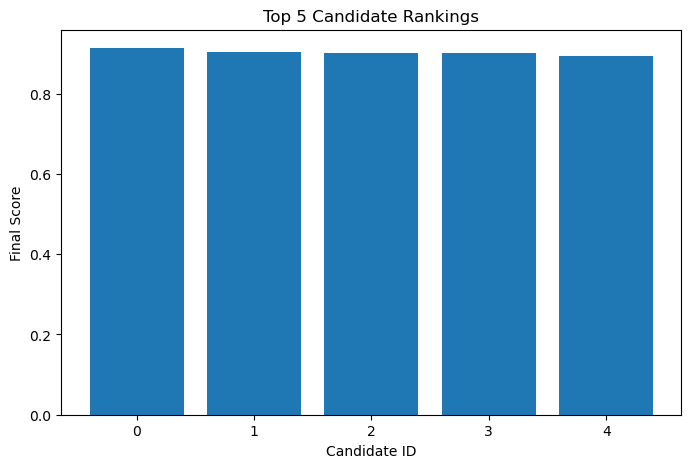

In [14]:
import matplotlib.pyplot as plt

top5 = final_output.head(5)

plt.figure(figsize=(8,5))
plt.bar(top5['Candidate_ID'].astype(str),
        top5['Final_Score'])
plt.title("Top 5 Candidate Rankings")
plt.xlabel("Candidate ID")
plt.ylabel("Final Score")
plt.show()

# ✅ Final Conclusion

The AI-based Resume Screening System successfully ranks candidates 
based on job relevance using a weighted scoring mechanism:

- 70% Similarity Score
- 30% Skill Matching Score

The system efficiently identifies the most suitable candidates 
for the given job description, reducing recruiter workload 
and improving hiring accuracy.

This project demonstrates practical implementation of 
AI-driven recruitment automation.